In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# To display plots properly
%matplotlib inline


In [2]:
df=pd.read_csv("Dataset.csv")

In [3]:
#Basic dataset Information

## Schema and Size
## Datatypes

rows, cols = df.shape
print(f"The dataset contains {rows} rows and {cols} columns.") #returns no.of rows and columns
df.columns  #returns what are the columns present in the dataset
print(df.dtypes)  #returns the datatypes

The dataset contains 9712 rows and 8 columns.
Age                                    int64
Gender                                   str
Avg_Daily_Screen_Time_hr             float64
Primary_Device                           str
Exceeded_Recommended_Limit              bool
Educational_to_Recreational_Ratio    float64
Health_Impacts                           str
Urban_or_Rural                           str
dtype: object


In [4]:
#check missing values

## Null Handling

# Check missing values
print(df.isnull().sum())

# Replace missing values
df['Health_Impacts'] = df['Health_Impacts'].fillna('No Health Impact')

# Check again
print(df.isnull().sum())

# Display data
print(df.head())

Age                                     0
Gender                                  0
Avg_Daily_Screen_Time_hr                0
Primary_Device                          0
Exceeded_Recommended_Limit              0
Educational_to_Recreational_Ratio       0
Health_Impacts                       3218
Urban_or_Rural                          0
dtype: int64
Age                                  0
Gender                               0
Avg_Daily_Screen_Time_hr             0
Primary_Device                       0
Exceeded_Recommended_Limit           0
Educational_to_Recreational_Ratio    0
Health_Impacts                       0
Urban_or_Rural                       0
dtype: int64
   Age  Gender  Avg_Daily_Screen_Time_hr Primary_Device  \
0   14    Male                      3.99     Smartphone   
1   11  Female                      4.61         Laptop   
2   18  Female                      3.73             TV   
3   15  Female                      1.21         Laptop   
4   12  Female                 

In [5]:
 #Verification of Categorical Consistencies

## Inconsistent Categories

print(df['Gender'].unique())
print(df['Primary_Device'].unique())
print(df['Exceeded_Recommended_Limit'].unique())
print(df['Urban_or_Rural'].unique())

<StringArray>
['Male', 'Female']
Length: 2, dtype: str
<StringArray>
['Smartphone', 'Laptop', 'TV', 'Tablet']
Length: 4, dtype: str
[ True False]
<StringArray>
['Urban', 'Rural']
Length: 2, dtype: str


In [6]:
## Handling Multi-label Categorical Column

df['Health_Impacts'].str.split(', ').explode().value_counts()

Health_Impacts
Poor Sleep          4868
No Health Impact    3218
Eye Strain          2382
Anxiety             1605
Obesity Risk        1217
Name: count, dtype: int64

In [7]:
##Creating Age Bands

def age_band(age):
    
    if age <= 9:
        return "Child"  ##5-9 as "Child"
    elif age <= 13:
        return "Pre-Teen" ##10-13 as "Pre-Teen"
    elif age <= 16:
        return "Teen"  ##14-16 as "Teen"
    elif age<=18:
        return "Senior Teen"  ## 17-18 as "Senior Teen"
    else:
        return "Out of Range" ## incase of Outliers

df["Age_Band"] = df["Age"].apply(age_band)

def screen_time_category(hours):
    if hours <= 2:
        return "Low"
    elif hours <= 4:
        return "Moderate"
    elif hours <= 6:
        return "High"
    else:
        return "Very High"

df["Screen_Time_Category"] = df["Avg_Daily_Screen_Time_hr"].apply(screen_time_category)


def device_type_category(device):
    if device in ["Smartphone", "Tablet", "Laptop"]:
        return "Portable"
    elif device in ["Desktop", "Smart TV"]:
        return "Wall-Mounted"
    else:
        return "Other"

df["Device_Type_Category"] = df["Primary_Device"].apply(device_type_category)


def usage_balance_category(ratio):
    if ratio < 0.5:
        return "Mostly Recreational"
    elif 0.5 <= ratio <= 1:
        return "Balanced"
    else:
        return "Mostly Educational"

df["Usage_Balance_Category"] = df["Educational_to_Recreational_Ratio"].apply(usage_balance_category)


def health_risk_level(impact):
    if pd.isna(impact) or impact == "None":
        return "No Risk"
    issues = str(impact).split(",")
    if len(issues) == 1:
        return "Moderate Risk"
    else:
        return "High Risk"

df["Health_Risk_Level"] = df["Health_Impacts"].apply(health_risk_level)


def calculate_edu_time(row):
    ratio = row["Educational_to_Recreational_Ratio"]
    total = row["Avg_Daily_Screen_Time_hr"]
    
    return (ratio * total) / (1 + ratio)

df["Educational_Time_hr"] = df.apply(calculate_edu_time, axis=1)
df["Educational_Time_hr"] = df["Educational_Time_hr"].round(3)


def calculate_rec_time(row):
    ratio = row["Educational_to_Recreational_Ratio"]
    total = row["Avg_Daily_Screen_Time_hr"]
    
    return total / (1 + ratio)

def convert_to_actual_time(decimal_hours):
    hours = int(decimal_hours)
    minutes = round((decimal_hours - hours) * 60)
    return f"{hours} hr {minutes} min"

df["Educational_Time_hr"] = df["Avg_Daily_Screen_Time_hr"] * df["Educational_to_Recreational_Ratio"] / (1 + df["Educational_to_Recreational_Ratio"])
df["Recreational_Time_hr"] = df["Avg_Daily_Screen_Time_hr"] - df["Educational_Time_hr"]

df["Educational_Time_Actual"] = df["Educational_Time_hr"].apply(convert_to_actual_time)
df["Recreational_Time_Actual"] = df["Recreational_Time_hr"].apply(convert_to_actual_time)

df[["Educational_Time_hr", "Educational_Time_Actual",
    "Recreational_Time_hr", "Recreational_Time_Actual"]].head()
df

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural,Age_Band,Screen_Time_Category,Device_Type_Category,Usage_Balance_Category,Health_Risk_Level,Educational_Time_hr,Recreational_Time_hr,Educational_Time_Actual,Recreational_Time_Actual
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban,Teen,Moderate,Portable,Mostly Recreational,High Risk,1.180141,2.809859,1 hr 11 min,2 hr 49 min
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban,Pre-Teen,High,Portable,Mostly Recreational,Moderate Risk,1.063846,3.546154,1 hr 4 min,3 hr 33 min
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban,Senior Teen,Moderate,Other,Mostly Recreational,Moderate Risk,0.904242,2.825758,0 hr 54 min,2 hr 50 min
3,15,Female,1.21,Laptop,False,0.39,No Health Impact,Urban,Teen,Low,Portable,Mostly Recreational,Moderate Risk,0.339496,0.870504,0 hr 20 min,0 hr 52 min
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban,Pre-Teen,High,Portable,Mostly Recreational,High Risk,1.936980,3.953020,1 hr 56 min,3 hr 57 min
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9707,17,Male,3.26,Smartphone,True,0.44,Poor Sleep,Urban,Senior Teen,Moderate,Portable,Mostly Recreational,Moderate Risk,0.996111,2.263889,0 hr 60 min,2 hr 16 min
9708,17,Female,4.43,Smartphone,True,0.40,Poor Sleep,Rural,Senior Teen,High,Portable,Mostly Recreational,Moderate Risk,1.265714,3.164286,1 hr 16 min,3 hr 10 min
9709,16,Male,5.62,Smartphone,True,0.39,"Poor Sleep, Eye Strain, Anxiety",Rural,Teen,High,Portable,Mostly Recreational,High Risk,1.576835,4.043165,1 hr 35 min,4 hr 3 min
9710,17,Male,5.60,TV,True,0.43,Poor Sleep,Urban,Senior Teen,High,Other,Mostly Recreational,Moderate Risk,1.683916,3.916084,1 hr 41 min,3 hr 55 min


In [8]:
df.to_csv("Cleaned_Dataset_ScreenSense.csv", index=False)

In [13]:
#   Cohort Analysis

cohort = pd.crosstab(df['Age_Band'], df['Device_Type_Category'])

print(cohort)

Device_Type_Category  Other  Portable
Age_Band                             
Child                   683      1114
Pre-Teen                895      2625
Senior Teen             366      1393
Teen                    543      2093


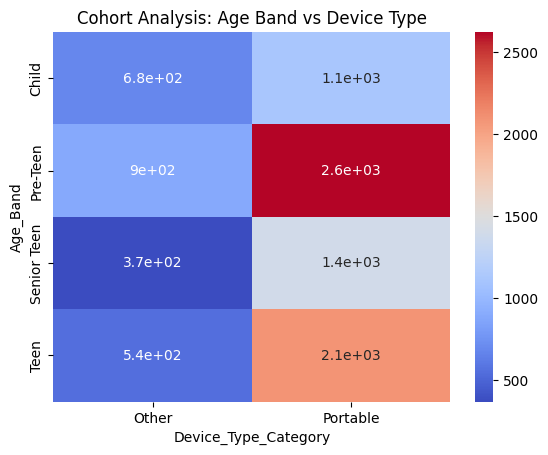

In [14]:
#   Age Band vs Device Type

cohort = pd.crosstab(df['Age_Band'], df['Device_Type_Category'])

sns.heatmap(cohort, annot=True, cmap='coolwarm')

plt.title("Cohort Analysis: Age Band vs Device Type")
plt.show()

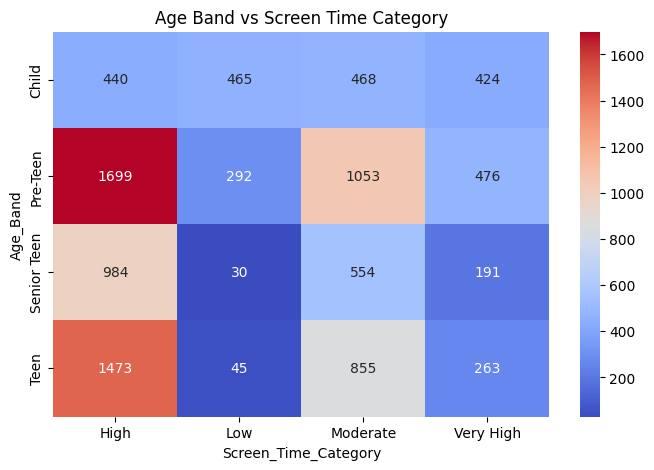

In [9]:
# Age Band vs Screen Time Category

cohort_screen = pd.crosstab(df["Age_Band"], df["Screen_Time_Category"])
plt.figure(figsize=(8,5))
sns.heatmap(cohort_screen, annot=True, cmap="coolwarm", fmt="d")
plt.title("Age Band vs Screen Time Category")
plt.show()

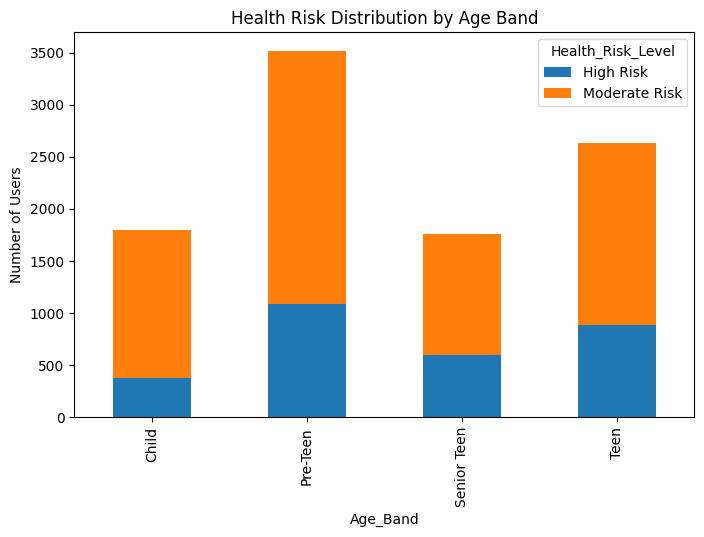

In [10]:
# Health Risk by Age Band

health_age = pd.crosstab(df["Age_Band"], df["Health_Risk_Level"])

health_age.plot(kind="bar", stacked=True, figsize=(8,5))
plt.title("Health Risk Distribution by Age Band")
plt.ylabel("Number of Users")
plt.show()

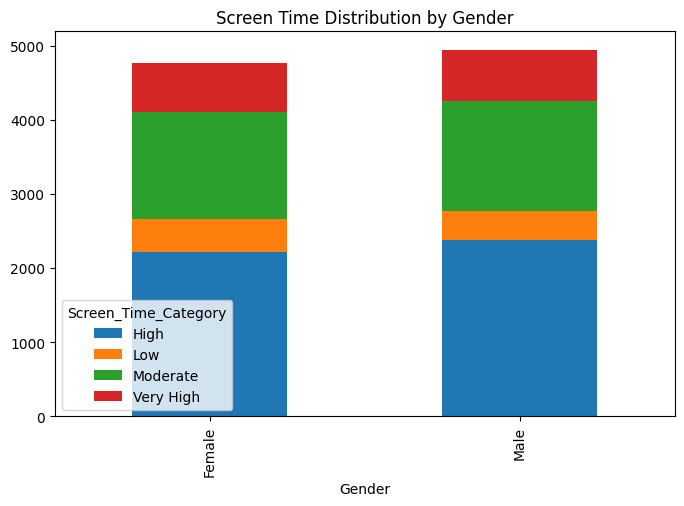

In [13]:
#  Screen Time by Gender

gender_screen = pd.crosstab(df["Gender"], df["Screen_Time_Category"])

gender_screen.plot(kind="bar", stacked=True, figsize=(8,5))
plt.title("Screen Time Distribution by Gender")
plt.show()

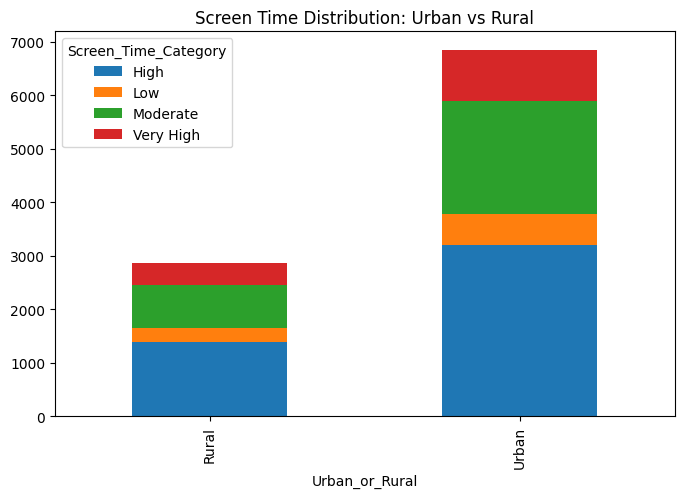

In [12]:
#Screen Time Urban vs Rural

urban_screen = pd.crosstab(df["Urban_or_Rural"], df["Screen_Time_Category"])

urban_screen.plot(kind="bar", stacked=True, figsize=(8,5))
plt.title("Screen Time Distribution: Urban vs Rural")
plt.show()

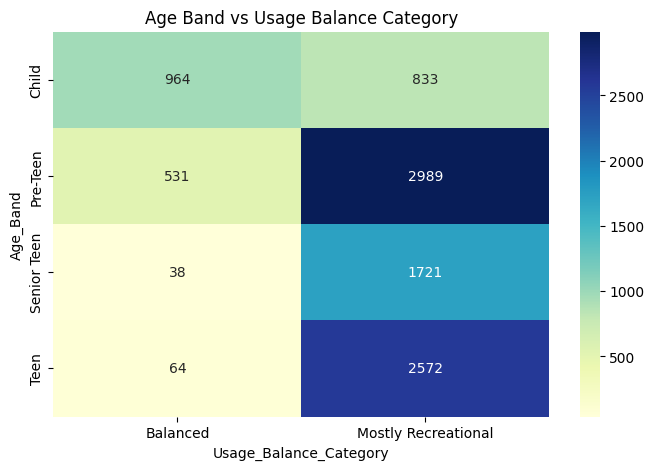

In [14]:
# Age Band x Usage Balance Category

usage_cohort = pd.crosstab(df["Age_Band"], df["Usage_Balance_Category"])

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.heatmap(usage_cohort, annot=True, cmap="YlGnBu", fmt="d")
plt.title("Age Band vs Usage Balance Category")
plt.show()

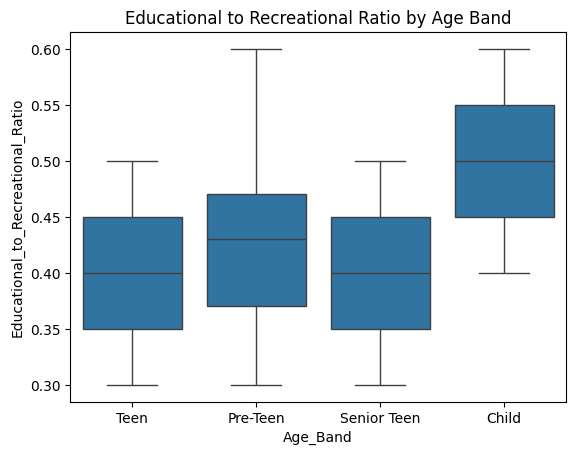

In [15]:
# Educational to Recreational Ratio by Age band

sns.boxplot(x="Age_Band", y="Educational_to_Recreational_Ratio", data=df)
plt.title("Educational to Recreational Ratio by Age Band")
plt.show()

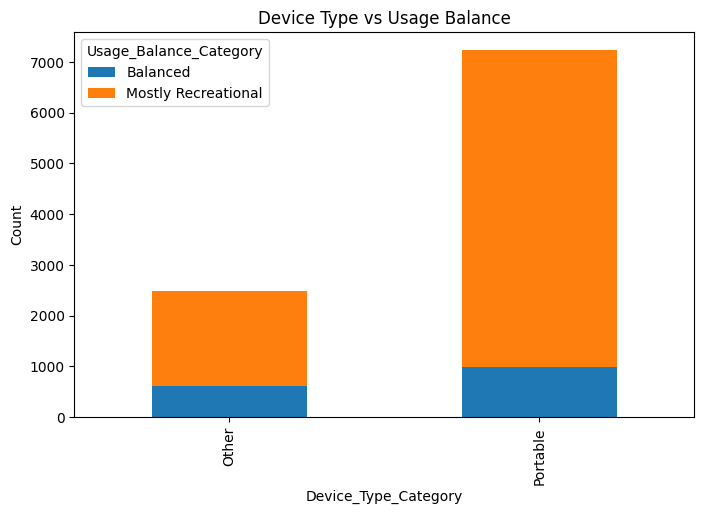

In [16]:
#  Device Type vs Usage Balance
device_usage = pd.crosstab(df["Device_Type_Category"], df["Usage_Balance_Category"])

device_usage.plot(kind="bar", stacked=True, figsize=(8,5))
plt.title("Device Type vs Usage Balance")
plt.ylabel("Count")
plt.show()

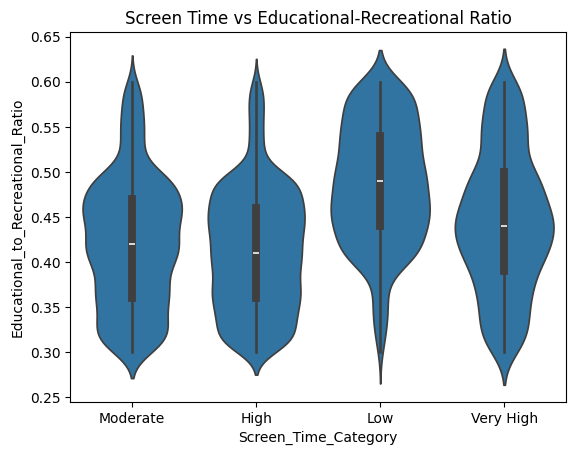

In [17]:
# Screen Time Category vs Educational-Recreational Ratio

sns.violinplot(x="Screen_Time_Category",
               y="Educational_to_Recreational_Ratio",
               data=df)

plt.title("Screen Time vs Educational-Recreational Ratio")
plt.show()

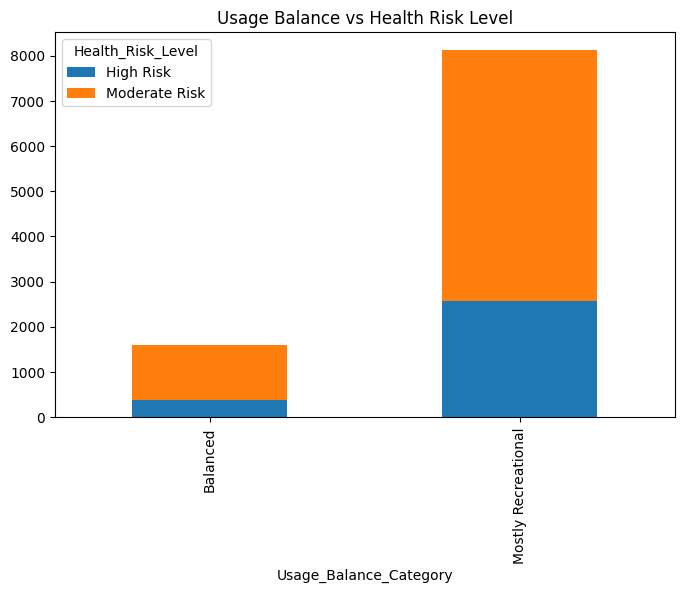

In [18]:
# Health Risk and Usage Balance

risk_usage = pd.crosstab(df["Usage_Balance_Category"], df["Health_Risk_Level"])

risk_usage.plot(kind="bar", stacked=True, figsize=(8,5))
plt.title("Usage Balance vs Health Risk Level")
plt.show()

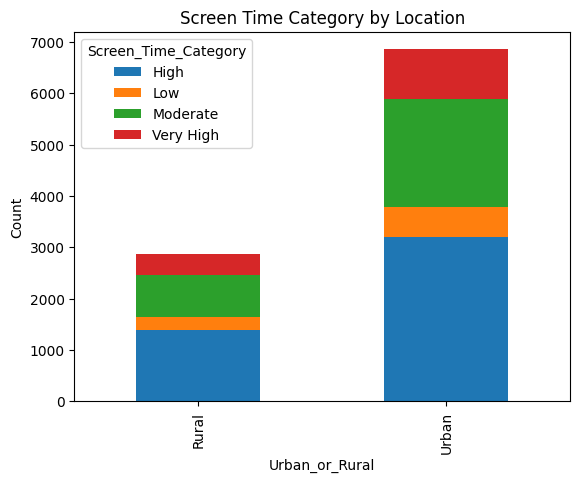

In [11]:
#   Segment ANalysis

#  Screen Time Category By Location

segment = pd.crosstab(df['Urban_or_Rural'], df['Screen_Time_Category'])

segment.plot(kind='bar', stacked=True)

plt.title("Screen Time Category by Location")
plt.ylabel("Count")
plt.show()

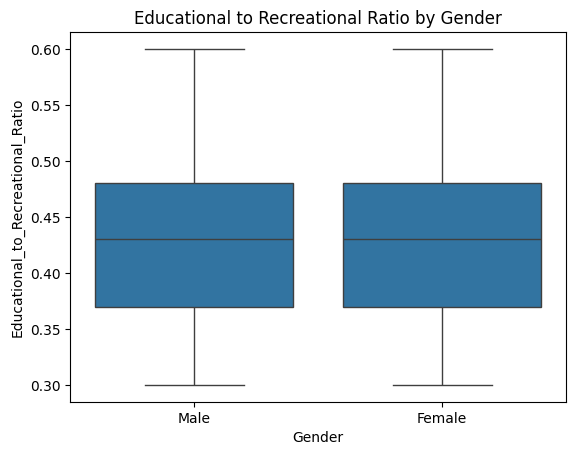

In [19]:
#  Gender vs Educational-Recreational Ratio

sns.boxplot(x="Gender", y="Educational_to_Recreational_Ratio", data=df)

plt.title("Educational to Recreational Ratio by Gender")
plt.show()

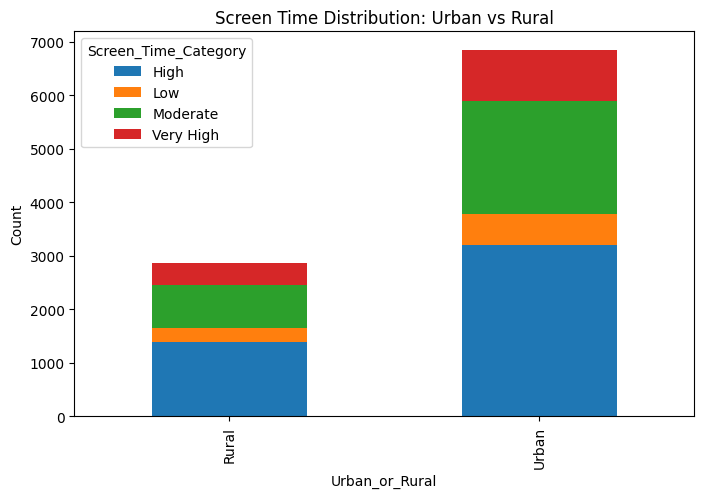

In [20]:
#Urban vs Rural Screen Time

urban_segment = pd.crosstab(df["Urban_or_Rural"], df["Screen_Time_Category"])

urban_segment.plot(kind="bar", stacked=True, figsize=(8,5))

plt.title("Screen Time Distribution: Urban vs Rural")
plt.ylabel("Count")
plt.show()

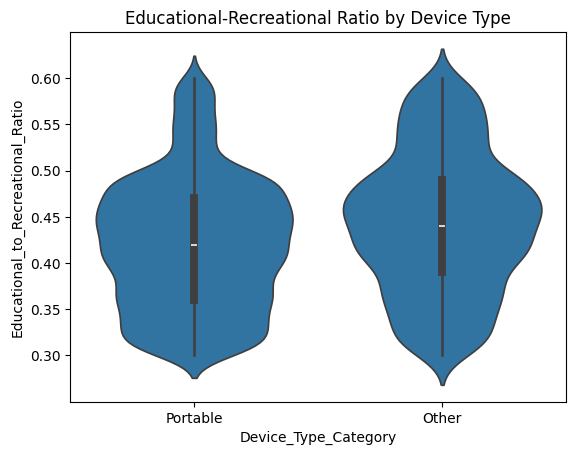

In [21]:
# Device Type vs Educational-Recreational Ratio

sns.violinplot(x="Device_Type_Category",
               y="Educational_to_Recreational_Ratio",
               data=df)

plt.title("Educational-Recreational Ratio by Device Type")
plt.show()

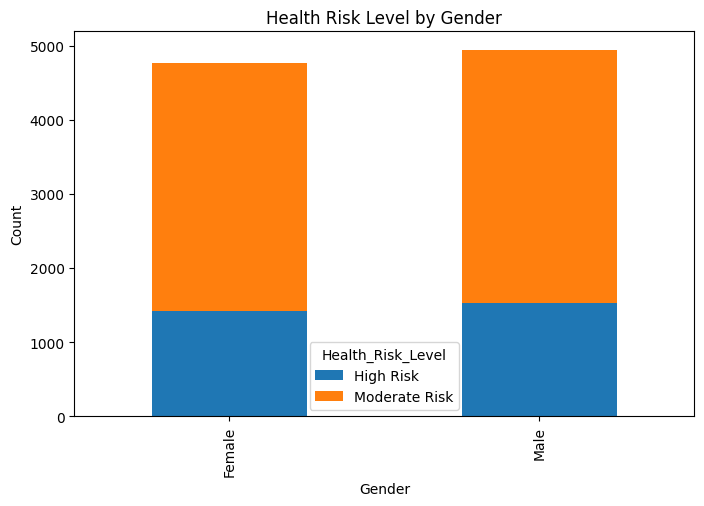

In [22]:
# Gender vs Health Risk Level

gender_health = pd.crosstab(df["Gender"], df["Health_Risk_Level"])

gender_health.plot(kind="bar", stacked=True, figsize=(8,5))

plt.title("Health Risk Level by Gender")
plt.ylabel("Count")
plt.show()

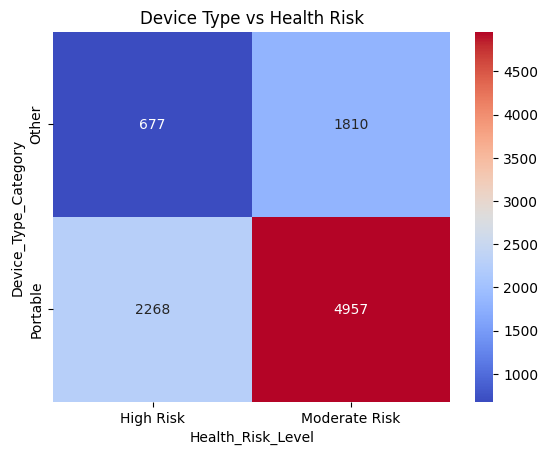

In [24]:
## Device Type vs Health Risk

sns.scatterplot(x="Educational_Time_hr",
                y="Recreational_Time_hr",
                hue="Urban_or_Rural",
                data=df)

plt.title("Educational vs Recreational Screen Time by Location")
plt.show()